In [2]:
!pip install ultralytics easyocr -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.6 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr
from google.colab import files, drive
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
drive.mount('/content/drive')

modelo_yolo = YOLO('/content/drive/MyDrive/Sudoku/modelo_entrenado/sudoku/weights/best.pt')
reader = easyocr.Reader(['en'])
print("Modelos cargados ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelos cargados ✓


Saving Captura de pantalla 2026-06-17 152439.png to Captura de pantalla 2026-06-17 152439.png

0: 640x480 1 sudoku, 61.8ms
Speed: 13.4ms preprocess, 61.8ms inference, 49.0ms postprocess per image at shape (1, 3, 640, 480)
✓ Recuadro detectado: 153,336 → 631,756


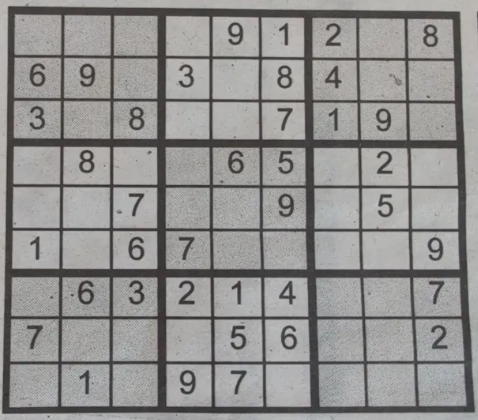

In [6]:
# Subir imagen
uploaded = files.upload()
nombre_imagen = list(uploaded.keys())[0]
imagen = cv2.imread(nombre_imagen)

# YOLO detecta el recuadro
results = modelo_yolo(imagen)

if len(results[0].boxes) == 0:
    print("❌ No se detectó ningún recuadro de sudoku")
else:
    x1, y1, x2, y2 = map(int, results[0].boxes.xyxy[0])
    img_recortada = results[0].orig_img[y1:y2, x1:x2]
    print(f"✓ Recuadro detectado: {x1},{y1} → {x2},{y2}")
    cv2_imshow(img_recortada)

✓ Perspectiva corregida


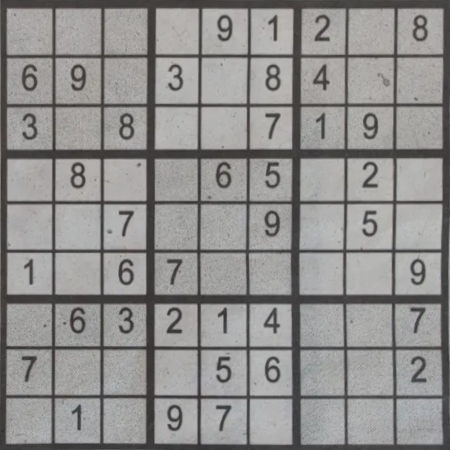

In [7]:
def corregir_perspectiva(img):
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gris, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contorno = max(contornos, key=cv2.contourArea)

    epsilon = 0.02 * cv2.arcLength(contorno, True)
    esquinas = cv2.approxPolyDP(contorno, epsilon, True)

    if len(esquinas) != 4:
        print("⚠️ No se encontraron 4 esquinas, usando imagen sin corregir")
        return img

    pts = esquinas.reshape(4, 2).astype('float32')
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    lado = 450
    dst = np.array([[0,0],[lado,0],[lado,lado],[0,lado]], dtype='float32')
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(img, M, (lado, lado))

img_corregida = corregir_perspectiva(img_recortada)
print("✓ Perspectiva corregida")
cv2_imshow(img_corregida)

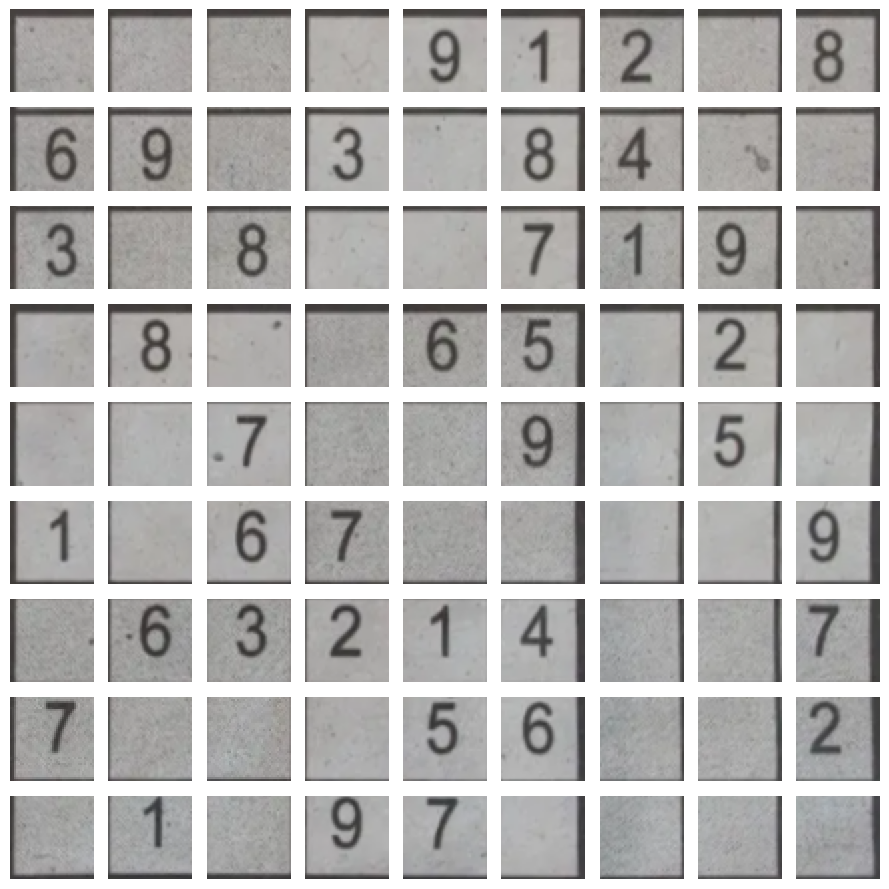

✓ 81 celdas generadas


In [8]:
alto, ancho = img_corregida.shape[:2]
celda_alto = alto // 9
celda_ancho = ancho // 9
MARGEN = 4

celdas = []
for fila in range(9):
    fila_celdas = []
    for col in range(9):
        y1c = fila * celda_alto + MARGEN
        y2c = y1c + celda_alto - MARGEN * 2
        x1c = col * celda_ancho + MARGEN
        x2c = x1c + celda_ancho - MARGEN * 2
        fila_celdas.append(img_corregida[y1c:y2c, x1c:x2c])
    celdas.append(fila_celdas)

fig, axes = plt.subplots(9, 9, figsize=(9, 9))
for fila in range(9):
    for col in range(9):
        celda_rgb = cv2.cvtColor(celdas[fila][col], cv2.COLOR_BGR2RGB)
        axes[fila][col].imshow(celda_rgb)
        axes[fila][col].axis('off')
plt.tight_layout()
plt.show()
print("✓ 81 celdas generadas")

In [9]:
def predecir_celda(celda):
    gris = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, (gris.shape[1]*3, gris.shape[0]*3), interpolation=cv2.INTER_CUBIC)
    resultado = reader.readtext(gris, allowlist='123456789', detail=1)
    if not resultado:
        return 0, 0.0
    texto = resultado[0][1]
    confianza = resultado[0][2]
    if texto.isdigit() and 1 <= int(texto) <= 9:
        return int(texto), confianza
    return 0, 0.0

sudoku = []
for fila in range(9):
    fila_nums = []
    for col in range(9):
        digito, _ = predecir_celda(celdas[fila][col])
        fila_nums.append(digito)
    sudoku.append(fila_nums)

print("Sudoku detectado:")
print("─" * 25)
for i, fila in enumerate(sudoku):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

Sudoku detectado:
─────────────────────────
0 0 0 │ 0 9 1 │ 2 0 8 
6 9 0 │ 3 0 8 │ 4 0 0 
3 0 8 │ 0 0 7 │ 1 9 0 
─────────────────────────
0 8 0 │ 0 6 5 │ 0 2 0 
0 0 7 │ 0 0 9 │ 0 5 0 
1 0 6 │ 7 0 0 │ 0 0 9 
─────────────────────────
0 6 3 │ 2 1 4 │ 0 0 7 
7 0 0 │ 0 5 6 │ 0 0 2 
0 1 0 │ 9 7 0 │ 0 0 0 


In [13]:
import pandas as pd
import numpy as np
from tensorflow import keras

df = pd.read_csv('/content/drive/MyDrive/Sudoku/sudoku.csv', nrows=100000)

X = np.array(df['puzzle'].apply(lambda x: [int(c) for c in x]).tolist()) / 9.0
y = np.array(df['solution'].apply(lambda x: [int(c) for c in x]).tolist()) - 1

print(f"✓ Datos cargados: {X.shape}")

✓ Datos cargados: (100000, 81)


In [15]:
from tensorflow import keras

modelo_sudoku = keras.Sequential([
    keras.layers.Reshape((9, 9, 1), input_shape=(81,)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(256, (1,1), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(9, (1,1), activation='softmax', padding='same'),
    keras.layers.Reshape((81, 9))
])

modelo_sudoku.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_sudoku.fit(X.reshape(-1, 81), y, epochs=20, batch_size=64, validation_split=0.1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.5756 - loss: 1.0836 - val_accuracy: 0.6074 - val_loss: 0.9725
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6409 - loss: 0.8324 - val_accuracy: 0.6574 - val_loss: 0.7673
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.6771 - loss: 0.7056 - val_accuracy: 0.6837 - val_loss: 0.6865
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6974 - loss: 0.6500 - val_accuracy: 0.7003 - val_loss: 0.6403
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7094 - loss: 0.6185 - val_accuracy: 0.7091 - val_loss: 0.6172
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7179 - loss: 0.5976 - val_accuracy: 0.7168 - val_loss: 0.5979
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7251 - loss: 0.5809 - val_accuracy: 0.7231 - val_loss: 0.5830
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7310 -

In [16]:
modelo_sudoku.save("modelo_sudoku.keras")
!cp modelo_sudoku.keras "/content/drive/MyDrive/Sudoku/"
print("✓ Guardado!")

✓ Guardado!


Solo predicción

In [17]:
def resolver_con_modelo(sudoku, modelo):
    puzzle = np.array([n for fila in sudoku for n in fila]).reshape(1, 81) / 9.0
    pred = modelo.predict(puzzle.reshape(-1, 81), verbose=0)
    solucion = np.argmax(pred[0], axis=1) + 1

    resultado = []
    for i in range(9):
        fila = []
        for j in range(9):
            if sudoku[i][j] != 0:
                fila.append(sudoku[i][j])
            else:
                fila.append(int(solucion[i*9 + j]))
        resultado.append(fila)
    return resultado

solucion = resolver_con_modelo(sudoku, modelo_sudoku)

print("Sudoku resuelto:")
print("─" * 25)
for i, fila in enumerate(solucion):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

Sudoku resuelto:
─────────────────────────
7 7 4 │ 6 9 1 │ 2 7 8 
6 9 1 │ 3 2 8 │ 4 7 6 
3 2 8 │ 6 2 7 │ 1 9 5 
─────────────────────────
4 8 9 │ 1 6 5 │ 7 2 1 
2 3 7 │ 1 3 9 │ 8 5 6 
1 3 6 │ 7 4 2 │ 8 1 9 
─────────────────────────
8 6 3 │ 2 1 4 │ 9 8 7 
7 2 2 │ 3 5 6 │ 9 1 2 
5 1 5 │ 9 7 8 │ 5 4 6 


Predicción y backtracking

In [19]:
import copy
import numpy as np

# ── 1. Detectar dígitos con EasyOCR ──────────────────────────
def predecir_celda(celda):
    gris = cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, (gris.shape[1]*3, gris.shape[0]*3), interpolation=cv2.INTER_CUBIC)
    resultado = reader.readtext(gris, allowlist='123456789', detail=1)
    if not resultado:
        return 0
    texto = resultado[0][1]
    confianza = resultado[0][2]
    if texto.isdigit() and 1 <= int(texto) <= 9:
        return int(texto)
    return 0

sudoku = []
for fila in range(9):
    fila_nums = []
    for col in range(9):
        digito = predecir_celda(celdas[fila][col])
        fila_nums.append(digito)
    sudoku.append(fila_nums)

print("Sudoku detectado:")
print("─" * 25)
for i, fila in enumerate(sudoku):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

# ── 2. Modelo CNN sugiere solución ───────────────────────────
puzzle = np.array([n for fila in sudoku for n in fila]).reshape(1, 81) / 9.0
pred = modelo_sudoku.predict(puzzle.reshape(-1, 81), verbose=0)
solucion_modelo = np.argmax(pred[0], axis=1) + 1

tablero = []
for i in range(9):
    fila = []
    for j in range(9):
        if sudoku[i][j] != 0:
            fila.append(sudoku[i][j])
        else:
            fila.append(int(solucion_modelo[i*9 + j]))
    tablero.append(fila)

# ── 3. Backtracking garantiza solución válida ─────────────────
def es_valido(t, fila, col, num):
    if num in t[fila]:
        return False
    if num in [t[i][col] for i in range(9)]:
        return False
    bf = (fila // 3) * 3
    bc = (col // 3) * 3
    for i in range(bf, bf + 3):
        for j in range(bc, bc + 3):
            if t[i][j] == num:
                return False
    return True

def backtrack(t):
    for i in range(9):
        for j in range(9):
            if sudoku[i][j] == 0:
                if not es_valido(t, i, j, t[i][j]):
                    t[i][j] = 0
                    for num in range(1, 10):
                        if es_valido(t, i, j, num):
                            t[i][j] = num
                            if backtrack(t):
                                return True
                            t[i][j] = 0
                    return False
    return True

backtrack(tablero)

print("\nSudoku resuelto:")
print("─" * 25)
for i, fila in enumerate(tablero):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

Sudoku detectado:
─────────────────────────
0 0 0 │ 0 9 1 │ 2 0 8 
6 9 0 │ 3 0 8 │ 4 0 0 
3 0 8 │ 0 0 7 │ 1 9 0 
─────────────────────────
0 8 0 │ 0 6 5 │ 0 2 0 
0 0 7 │ 0 0 9 │ 0 5 0 
1 0 6 │ 7 0 0 │ 0 0 9 
─────────────────────────
0 6 3 │ 2 1 4 │ 0 0 7 
7 0 0 │ 0 5 6 │ 0 0 2 
0 1 0 │ 9 7 0 │ 0 0 0 

Sudoku resuelto:
─────────────────────────
0 7 4 │ 6 9 1 │ 2 7 8 
6 9 1 │ 3 2 8 │ 4 7 6 
3 2 8 │ 6 2 7 │ 1 9 5 
─────────────────────────
4 8 9 │ 1 6 5 │ 7 2 1 
2 3 7 │ 1 3 9 │ 8 5 6 
1 3 6 │ 7 4 2 │ 8 1 9 
─────────────────────────
8 6 3 │ 2 1 4 │ 9 8 7 
7 2 2 │ 3 5 6 │ 9 1 2 
5 1 5 │ 9 7 8 │ 5 4 6 


Solo bakctracking

In [20]:
def es_valido(t, fila, col, num):
    if num in t[fila]:
        return False
    if num in [t[i][col] for i in range(9)]:
        return False
    bf = (fila // 3) * 3
    bc = (col // 3) * 3
    for i in range(bf, bf + 3):
        for j in range(bc, bc + 3):
            if t[i][j] == num:
                return False
    return True

def backtrack(t):
    for i in range(9):
        for j in range(9):
            if t[i][j] == 0:
                for num in range(1, 10):
                    if es_valido(t, i, j, num):
                        t[i][j] = num
                        if backtrack(t):
                            return True
                        t[i][j] = 0
                return False
    return True

import copy
tablero = copy.deepcopy(sudoku)
backtrack(tablero)

print("Sudoku resuelto:")
print("─" * 25)
for i, fila in enumerate(tablero):
    if i % 3 == 0 and i != 0:
        print("─" * 25)
    fila_str = ""
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0:
            fila_str += "│ "
        fila_str += f"{num} "
    print(fila_str)

Sudoku resuelto:
─────────────────────────
4 7 5 │ 6 9 1 │ 2 3 8 
6 9 1 │ 3 2 8 │ 4 7 5 
3 2 8 │ 5 4 7 │ 1 9 6 
─────────────────────────
9 8 4 │ 1 6 5 │ 7 2 3 
2 3 7 │ 4 8 9 │ 6 5 1 
1 5 6 │ 7 3 2 │ 8 4 9 
─────────────────────────
5 6 3 │ 2 1 4 │ 9 8 7 
7 4 9 │ 8 5 6 │ 3 1 2 
8 1 2 │ 9 7 3 │ 5 6 4 


In [21]:
from google.colab import files
files.download('/content/drive/MyDrive/Sudoku/modelo_entrenado/sudoku/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>